# Klasifikasi Botol Parfum dengan SVM

Notebook ini menganalisis dataset foto tiga botol parfum yang saya ambil sendiri, lalu melatih classifier SVM untuk membedakan ketiganya berdasarkan warna dan tekstur. Fokusnya bukan hanya angka akurasi, tapi juga menunjukkan tantangan nyata di dataset seperti foto yang blur atau latar belakang yang mirip antar kelas.

Tiga kelasnya:
- **Perfume-1**: botol kaca heksagonal, gradasi merah muda ke oranye, tutup emas.
- **Perfume-2**: botol kaca frosted hijau pucat, bentuk silinder, tutup krem.
- **Perfume-3**: botol kaca kotak transparan berlabel, tutup hitam.

In [1]:
import os
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from skimage.feature import hog
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATASET_DIR = "dataset"
IMG_SIZE = 256

## Memuat Dataset

Dataset ada di folder `dataset/`, satu subfolder per kelas. Setiap foto dibaca lalu langsung diresize ke ukuran kecil supaya tidak membebani memori, karena ukuran aslinya sekitar 3472x3472 piksel.

In [2]:
def list_image_paths(dataset_dir):
    records = []
    for class_name in sorted(os.listdir(dataset_dir)):
        class_dir = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for path in sorted(glob.glob(os.path.join(class_dir, "*.jpg"))):
            records.append({"path": path, "label": class_name})
    return pd.DataFrame(records)


def load_image(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img


df = list_image_paths(DATASET_DIR)
df["label"].value_counts()

label
Perfume-1    16
Perfume-2    15
Perfume-3    15
Name: count, dtype: int64

## Sebaran Ukuran Foto Asli

Sebelum diresize, foto-fotonya tidak seragam. Sebagian besar berukuran 3472x3472, tapi empat foto pertama Perfume-3 diambil sehari sebelumnya dengan rasio potret 3472x4624, karena pengaturan kamera yang berubah antar sesi pemotretan.

In [3]:
original_sizes = [Image.open(p).size for p in df["path"]]
pd.Series(original_sizes).value_counts()

(3472, 3472)    42
(3472, 4624)     4
Name: count, dtype: int64

## Melihat Contoh Tiap Kelas

Sebelum masuk ke ekstraksi fitur, ada baiknya melihat langsung seperti apa tiap kelas. Grid di bawah menampilkan lima sampel acak per kelas.

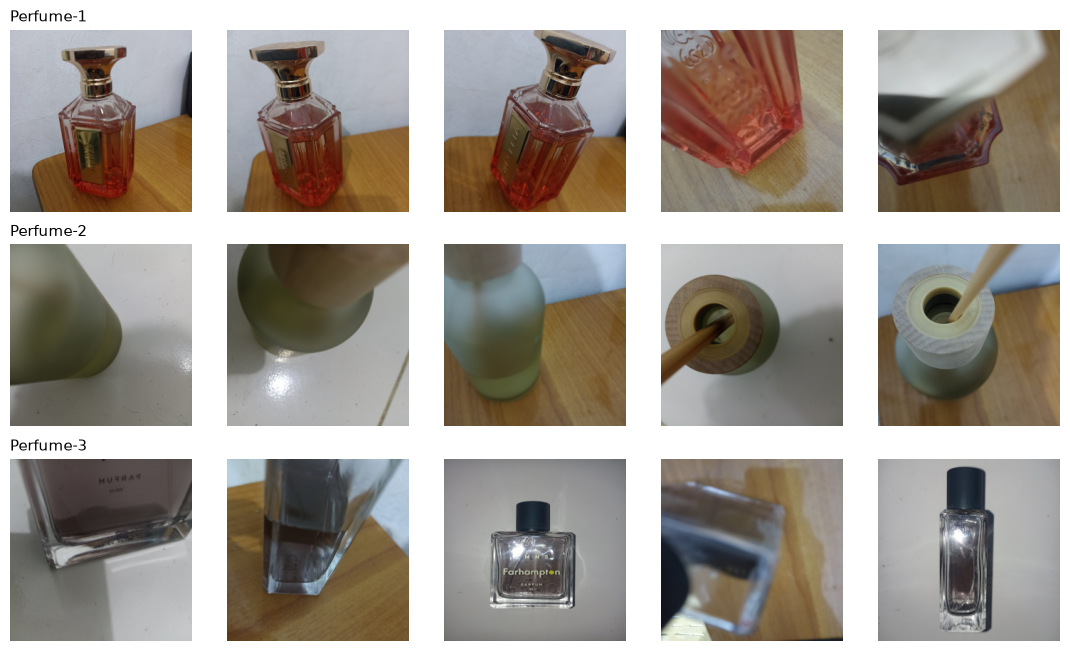

In [4]:
def show_samples(df, n_per_class=5, size=IMG_SIZE):
    classes = sorted(df["label"].unique())
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 2.2, len(classes) * 2.2))
    for row, class_name in enumerate(classes):
        subset = df[df["label"] == class_name].sample(n=n_per_class, random_state=RANDOM_STATE)
        for col, path in enumerate(subset["path"]):
            axes[row, col].imshow(load_image(path, size))
            axes[row, col].axis("off")
        axes[row, 0].set_title(class_name, loc="left", fontsize=11)
    plt.tight_layout()
    plt.show()


show_samples(df)

## Mengukur Ketajaman Foto

Saat meninjau ulang dataset, hampir seluruh foto Perfume-2 terasa buram karena diambil terlalu dekat sampai kamera gagal fokus. Untuk mengukur ini secara objektif, saya pakai varians dari Laplacian tiap foto. Nilai varians yang rendah menandakan foto kurang tajam.

In [5]:
def sharpness(path, size=IMG_SIZE):
    img = load_image(path, size)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


df["sharpness"] = df["path"].apply(sharpness)
df.groupby("label")["sharpness"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Perfume-1,16.0,266.851346,160.544779,40.097134,137.156705,283.372729,367.945496,521.486804
Perfume-2,15.0,32.903923,19.608237,6.939757,15.007719,35.281688,44.689864,62.798703
Perfume-3,15.0,261.475861,216.240533,19.422772,118.689057,202.466490,329.468575,709.673250


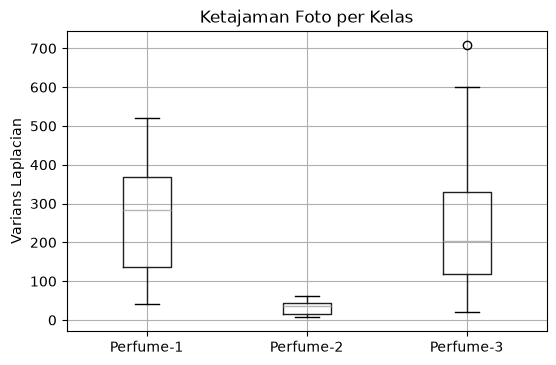

In [6]:
df.boxplot(column="sharpness", by="label", figsize=(6, 4))
plt.title("Ketajaman Foto per Kelas")
plt.suptitle("")
plt.ylabel("Varians Laplacian")
plt.xlabel("")
plt.show()

## Profil Warna per Kelas

Selain ketajaman, warna dominan tiap botol juga jadi pembeda utama antar kelas. Bagian ini menghitung rata-rata nilai Hue, Saturation, dan Value dari setiap foto.

In [7]:
def mean_hsv(path, size=IMG_SIZE):
    img = load_image(path, size)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    return hsv.reshape(-1, 3).mean(axis=0)


hsv_means = np.stack(df["path"].apply(mean_hsv))
df[["mean_h", "mean_s", "mean_v"]] = hsv_means
df.groupby("label")[["mean_h", "mean_s", "mean_v"]].mean()

,mean_h,mean_s,mean_v
label,,,
Perfume-1,50.902467,81.312963,138.102214
Perfume-2,50.021469,64.001073,127.060998
Perfume-3,61.845267,32.359998,131.590674


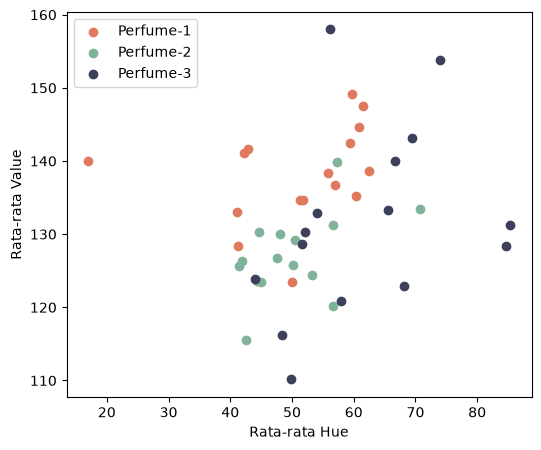

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
for class_name, color in zip(sorted(df["label"].unique()), ["#e07a5f", "#81b29a", "#3d405b"]):
    subset = df[df["label"] == class_name]
    ax.scatter(subset["mean_h"], subset["mean_v"], label=class_name, color=color)
ax.set_xlabel("Rata-rata Hue")
ax.set_ylabel("Rata-rata Value")
ax.legend()
plt.show()

## Ekstraksi Fitur untuk SVM

SVM butuh fitur numerik, bukan piksel mentah. Saya gabungkan dua jenis fitur: histogram warna HSV untuk menangkap warna dominan, dan HOG (Histogram of Oriented Gradients) untuk menangkap bentuk serta tekstur tepi botol.

In [9]:
def color_histogram(img, bins=16):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hist = [cv2.calcHist([hsv], [ch], None, [bins], [0, 256]).flatten() for ch in range(3)]
    hist = np.concatenate(hist)
    return hist / (hist.sum() + 1e-6)


def hog_features(img, resize_to=128):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (resize_to, resize_to))
    return hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2))


def extract_features(path, size=IMG_SIZE):
    img = load_image(path, size)
    return np.concatenate([color_histogram(img), hog_features(img)])


features = np.stack(df["path"].apply(extract_features))
features.shape

(46, 1812)

## Split Data dan Standardisasi

Datanya kecil, jadi saya pisahkan 80% untuk latih dan 20% untuk uji, tetap dengan stratifikasi supaya proporsi tiap kelas terjaga. Indeksnya disimpan supaya foto uji bisa dilacak balik untuk pengecekan visual nanti. Fitur juga distandardisasi karena skala histogram warna dan HOG jauh berbeda.

In [10]:
X = features
y = df["label"].values
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
test_paths = df.iloc[test_idx]["path"].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((36, 1812), (10, 1812))

## Mencari Parameter Terbaik

Kernel RBF pada SVM punya dua parameter penting, C dan gamma. Saya cari kombinasi terbaik lewat grid search dengan 5-fold cross-validation di atas data latih saja, supaya data uji tetap murni tidak tersentuh selama pencarian parameter.

In [11]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"],
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train_scaled, y_train)

grid.best_params_, grid.best_score_

({'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, np.float64(0.5928571428571427))

## Validasi Silang di Seluruh Data

Dataset ini kecil, jadi satu kali split train-test bisa menyesatkan kalau kebetulan dapat pembagian yang mudah atau sulit. Untuk gambaran yang lebih stabil, saya jalankan 5-fold cross-validation memakai parameter terbaik di atas seluruh 46 foto.

In [12]:
best_svm = SVC(**grid.best_params_)
X_scaled_full = StandardScaler().fit_transform(X)

cv_scores = cross_val_score(
    best_svm,
    X_scaled_full,
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
)
cv_scores, cv_scores.mean()

(array([0.9       , 0.55555556, 0.77777778, 0.55555556, 0.77777778]),
 np.float64(0.7133333333333333))

## Evaluasi di Data Uji

Sekarang lihat performa model pada data uji yang belum pernah dilihat sama sekali, baik selama training maupun grid search.

In [13]:
best_svm.fit(X_train_scaled, y_train)
y_pred = best_svm.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Perfume-1       1.00      0.50      0.67         4
   Perfume-2       0.38      1.00      0.55         3
   Perfume-3       0.00      0.00      0.00         3

    accuracy                           0.50        10
   macro avg       0.46      0.50      0.40        10
weighted avg       0.51      0.50      0.43        10



C:\Users\Syauqi Nabil\Lectures\University\Semester 5\Computer Vision\Task\image-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Syauqi Nabil\Lectures\University\Semester 5\Computer Vision\Task\image-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Syauqi Nabil\Lectures\University\Semester 5\Computer Vision\Task\image-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill

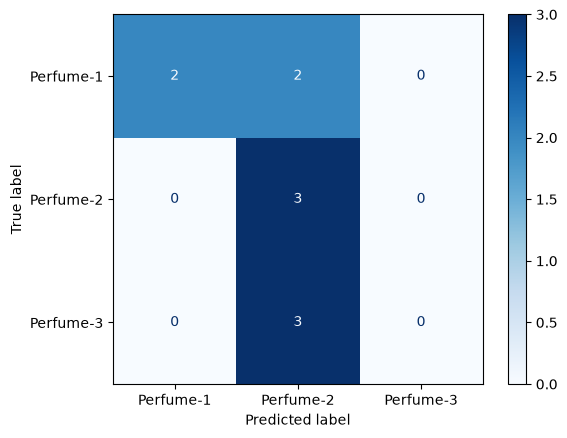

In [14]:
labels_sorted = sorted(df["label"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
disp = ConfusionMatrixDisplay(cm, display_labels=labels_sorted)
disp.plot(cmap="Blues")
plt.show()

## Melihat Foto yang Salah Diklasifikasikan

Angka akurasi saja tidak cerita banyak soal pola kesalahannya. Bagian ini menampilkan foto uji yang salah diprediksi, kalau ada.

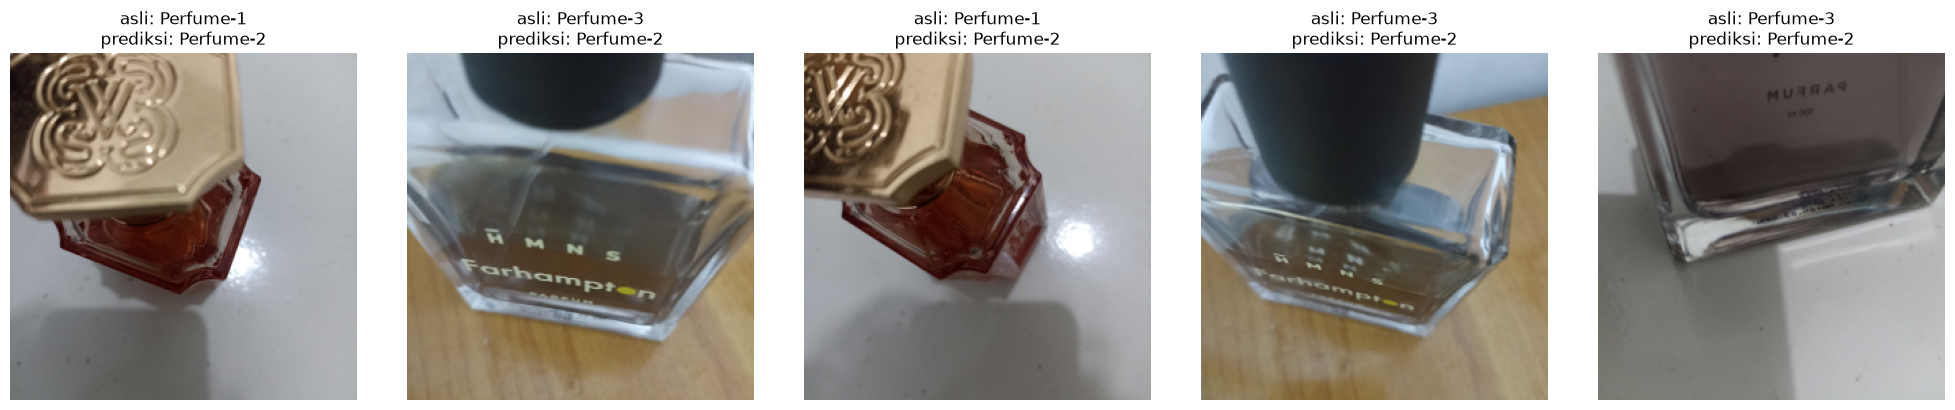

In [15]:
mismatch_idx = np.where(y_test != y_pred)[0]

if len(mismatch_idx) == 0:
    print("Tidak ada foto yang salah diprediksi di data uji ini.")
else:
    fig, axes = plt.subplots(1, len(mismatch_idx), figsize=(4 * len(mismatch_idx), 4))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, mismatch_idx):
        ax.imshow(load_image(test_paths[i]))
        ax.set_title(f"asli: {y_test[i]}\nprediksi: {y_pred[i]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Catatan Penutup

Model ini mendapat akurasi cross-validation sekitar 71% dan akurasi test set 50% pada satu kali split. Selisih ini terjadi karena test set hanya berisi 10 foto, jadi satu foto yang salah diprediksi sudah menggeser recall sampai 33%. Angka ini bukan patokan performa yang stabil, tapi cukup untuk melihat pola kesalahannya.

Data ketajaman gambar menunjukkan alasan konkretnya: rata-rata varians Laplacian Perfume-2 sekitar 33, jauh di bawah Perfume-1 (sekitar 267) dan Perfume-3 (sekitar 261). Foto yang buram membuat fitur HOG-nya tidak menangkap tepi botol dengan jelas, sehingga model lebih sering keliru saat foto uji berasal dari kelas ini.

Kalau proyek ini dilanjutkan, memotret ulang Perfume-2 dengan jarak yang cukup supaya kamera bisa fokus kemungkinan besar akan menaikkan akurasi lebih banyak dibanding mengganti algoritma atau menambah fitur. Menambah jumlah foto per kelas juga akan membuat metrik evaluasi lebih stabil dan tidak terlalu sensitif terhadap satu atau dua foto uji.